Exercise 1 — Alpha Diversity vs. Day Relative to HCT
Alpha diversity quantifies within-sample taxonomic richness. We use inverse Simpson.

Compute D per sample from tblcounts_asv_melt.csv. Merge with tblASVsamples.csv on SampleID to attach DayRelativeToNearestHCT. Restrict to the window [−15,+35] days, bin by integer day, and plot mean ± SEM vs. day with a vertical line at day 0.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

In [29]:
tblASVsamples = pd.read_csv("samples/tblASVsamples.csv")
tblASVtaxonomy_silva132_v4v5_filter = pd.read_csv("taxonomy/tblASVtaxonomy_silva132_v4v5_filter.csv")

In [30]:
tblcounts_asv_melt = pd.read_csv("counts/tblcounts_asv_melt.csv")
tbldrug = pd.read_csv("meta_data/tbldrug.csv")

C:\Users\aeriab\AppData\Local\Temp\ipykernel_10372\1839638042.py:2: DtypeWarning: Columns (0: PatientID) have mixed types. Specify dtype option on import or set low_memory=False.
  tbldrug = pd.read_csv("meta_data/tbldrug.csv")


In [43]:
D_vals_tblcounts_asv_melt = tblcounts_asv_melt.copy()

# 1. Calculate Proportion: Count / Total Count per SampleID
D_vals_tblcounts_asv_melt["Proportion"] = (
    D_vals_tblcounts_asv_melt["Count"] / 
    D_vals_tblcounts_asv_melt.groupby("SampleID")["Count"].transform("sum")
)

# 2. Calculate Dval: 1 / sum(Proportion^2) per SampleID
D_vals_tblcounts_asv_melt["Dval"] = 1 / (
    D_vals_tblcounts_asv_melt.assign(prop_sq=D_vals_tblcounts_asv_melt["Proportion"] ** 2)
    .groupby("SampleID")["prop_sq"]
    .transform("sum")
)

D_vals_tblcounts_asv_melt.head()

,SampleID,ASV,Count,Dval,Proportion
0,1000A,ASV_1216,14,13.289526,0.001145
1,1000A,ASV_12580,150,13.289526,0.012270
2,1000A,ASV_12691,260,13.289526,0.021268
3,1000A,ASV_135,434,13.289526,0.035501
4,1000A,ASV_147,79,13.289526,0.006462


In [44]:
Dvals_merge_samples = pd.merge(D_vals_tblcounts_asv_melt, tblASVsamples, on="SampleID")
Dvals_merge_samples.head()

,SampleID,ASV,Count,Dval,Proportion,PatientID,Timepoint,Consistency,Accession,BioProject,DayRelativeToNearestHCT,AccessionShotgun,Pool,Run,ShotgunBatchID
0,1000A,ASV_1216,14,13.289526,0.001145,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
1,1000A,ASV_12580,150,13.289526,0.012270,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
2,1000A,ASV_12691,260,13.289526,0.021268,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
3,1000A,ASV_135,434,13.289526,0.035501,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
4,1000A,ASV_147,79,13.289526,0.006462,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN


In [47]:
restricted_Dvals_merge_samples = Dvals_merge_samples[
    (Dvals_merge_samples["DayRelativeToNearestHCT"] >= -15.0) & 
    (Dvals_merge_samples["DayRelativeToNearestHCT"] <= 35.0)
]
restricted_Dvals_merge_samples.head()

,SampleID,ASV,Count,Dval,Proportion,PatientID,Timepoint,Consistency,Accession,BioProject,DayRelativeToNearestHCT,AccessionShotgun,Pool,Run,ShotgunBatchID
0,1000A,ASV_1216,14,13.289526,0.001145,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
1,1000A,ASV_12580,150,13.289526,0.012270,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
2,1000A,ASV_12691,260,13.289526,0.021268,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
3,1000A,ASV_135,434,13.289526,0.035501,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN
4,1000A,ASV_147,79,13.289526,0.006462,1000,0,formed,SRR11414397,PRJNA545312,-9.0,NaN,483,Miseq.66,NaN


In [48]:
bins = np.arange(-15.5,+36.5)
print(bins)

[-15.5 -14.5 -13.5 -12.5 -11.5 -10.5  -9.5  -8.5  -7.5  -6.5  -5.5  -4.5
  -3.5  -2.5  -1.5  -0.5   0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5
   8.5   9.5  10.5  11.5  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5
  20.5  21.5  22.5  23.5  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5
  32.5  33.5  34.5  35.5]


<Axes: >

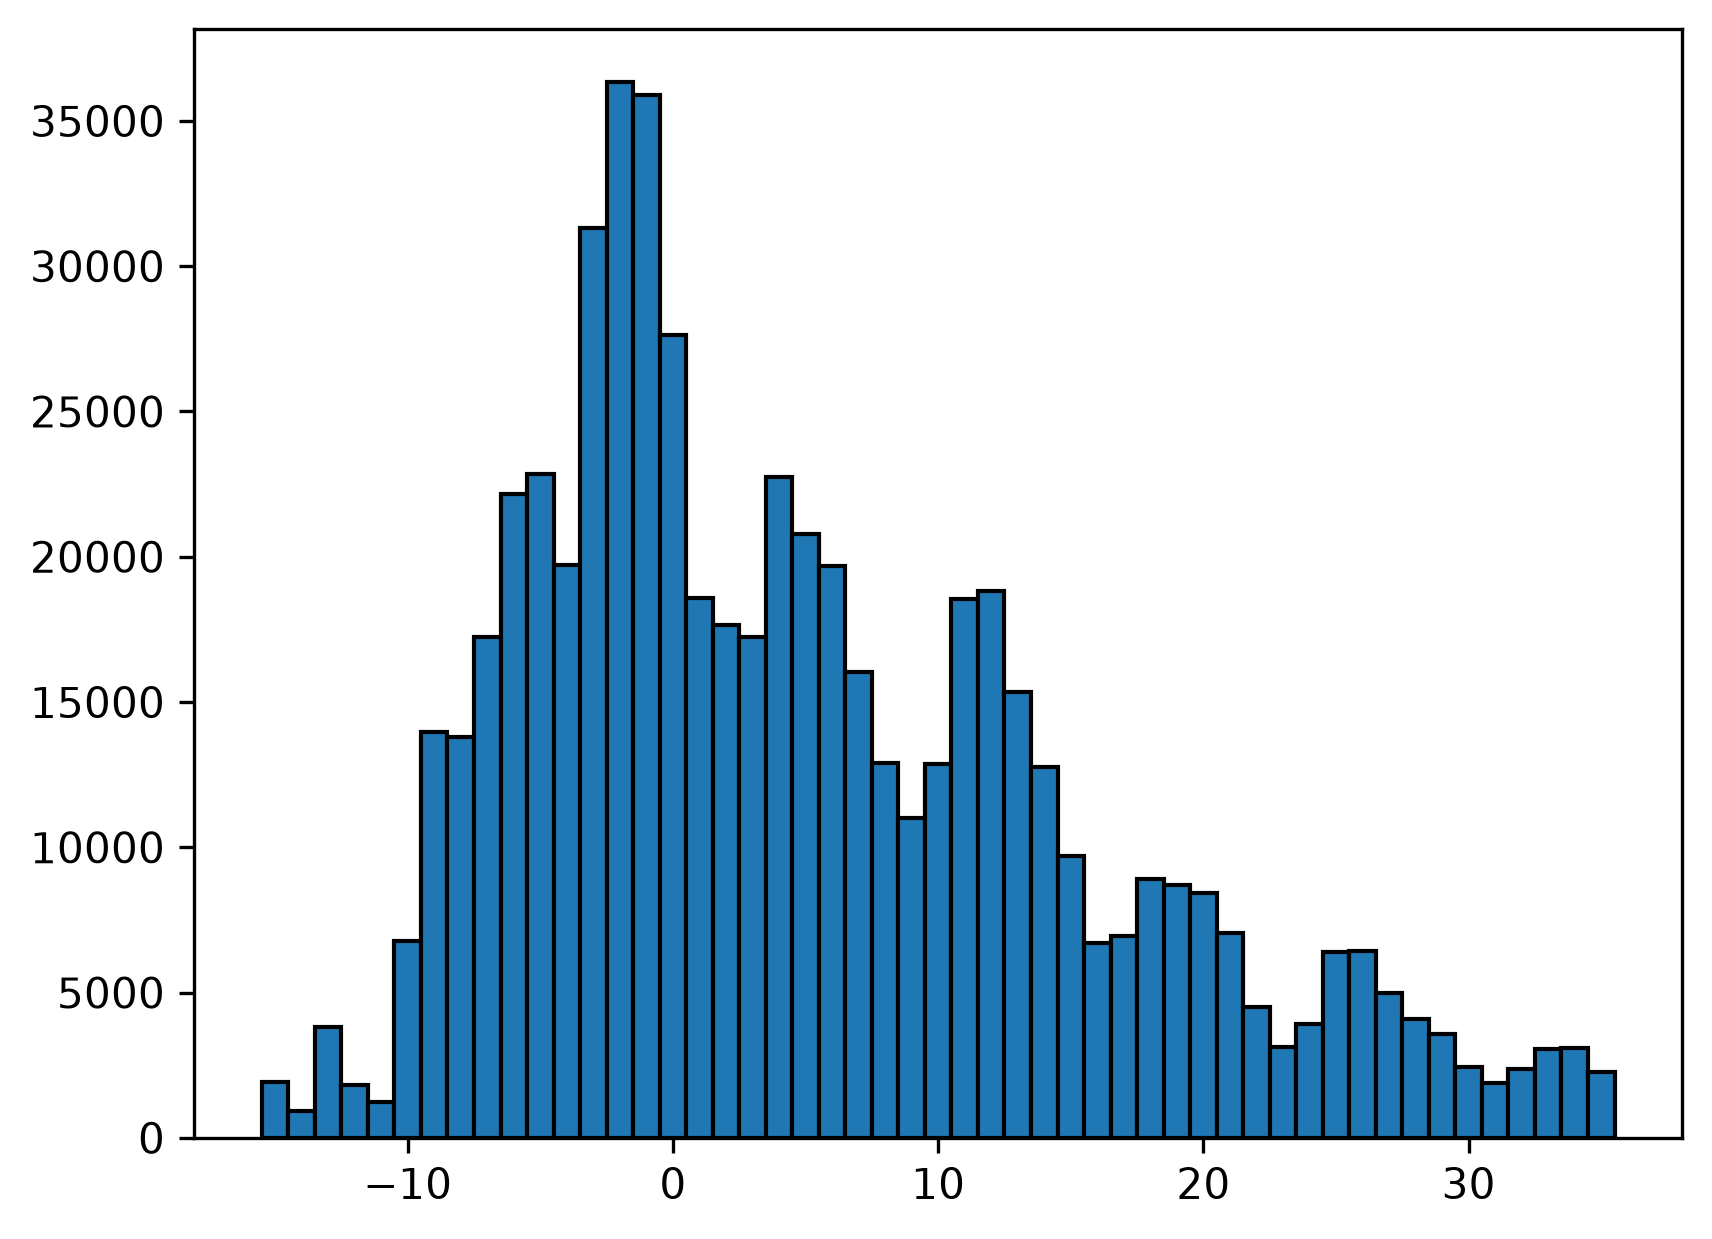

In [55]:
restricted_Dvals_merge_samples["DayRelativeToNearestHCT"].hist(
    bins=bins,
    edgecolor='black',
    grid=False
)

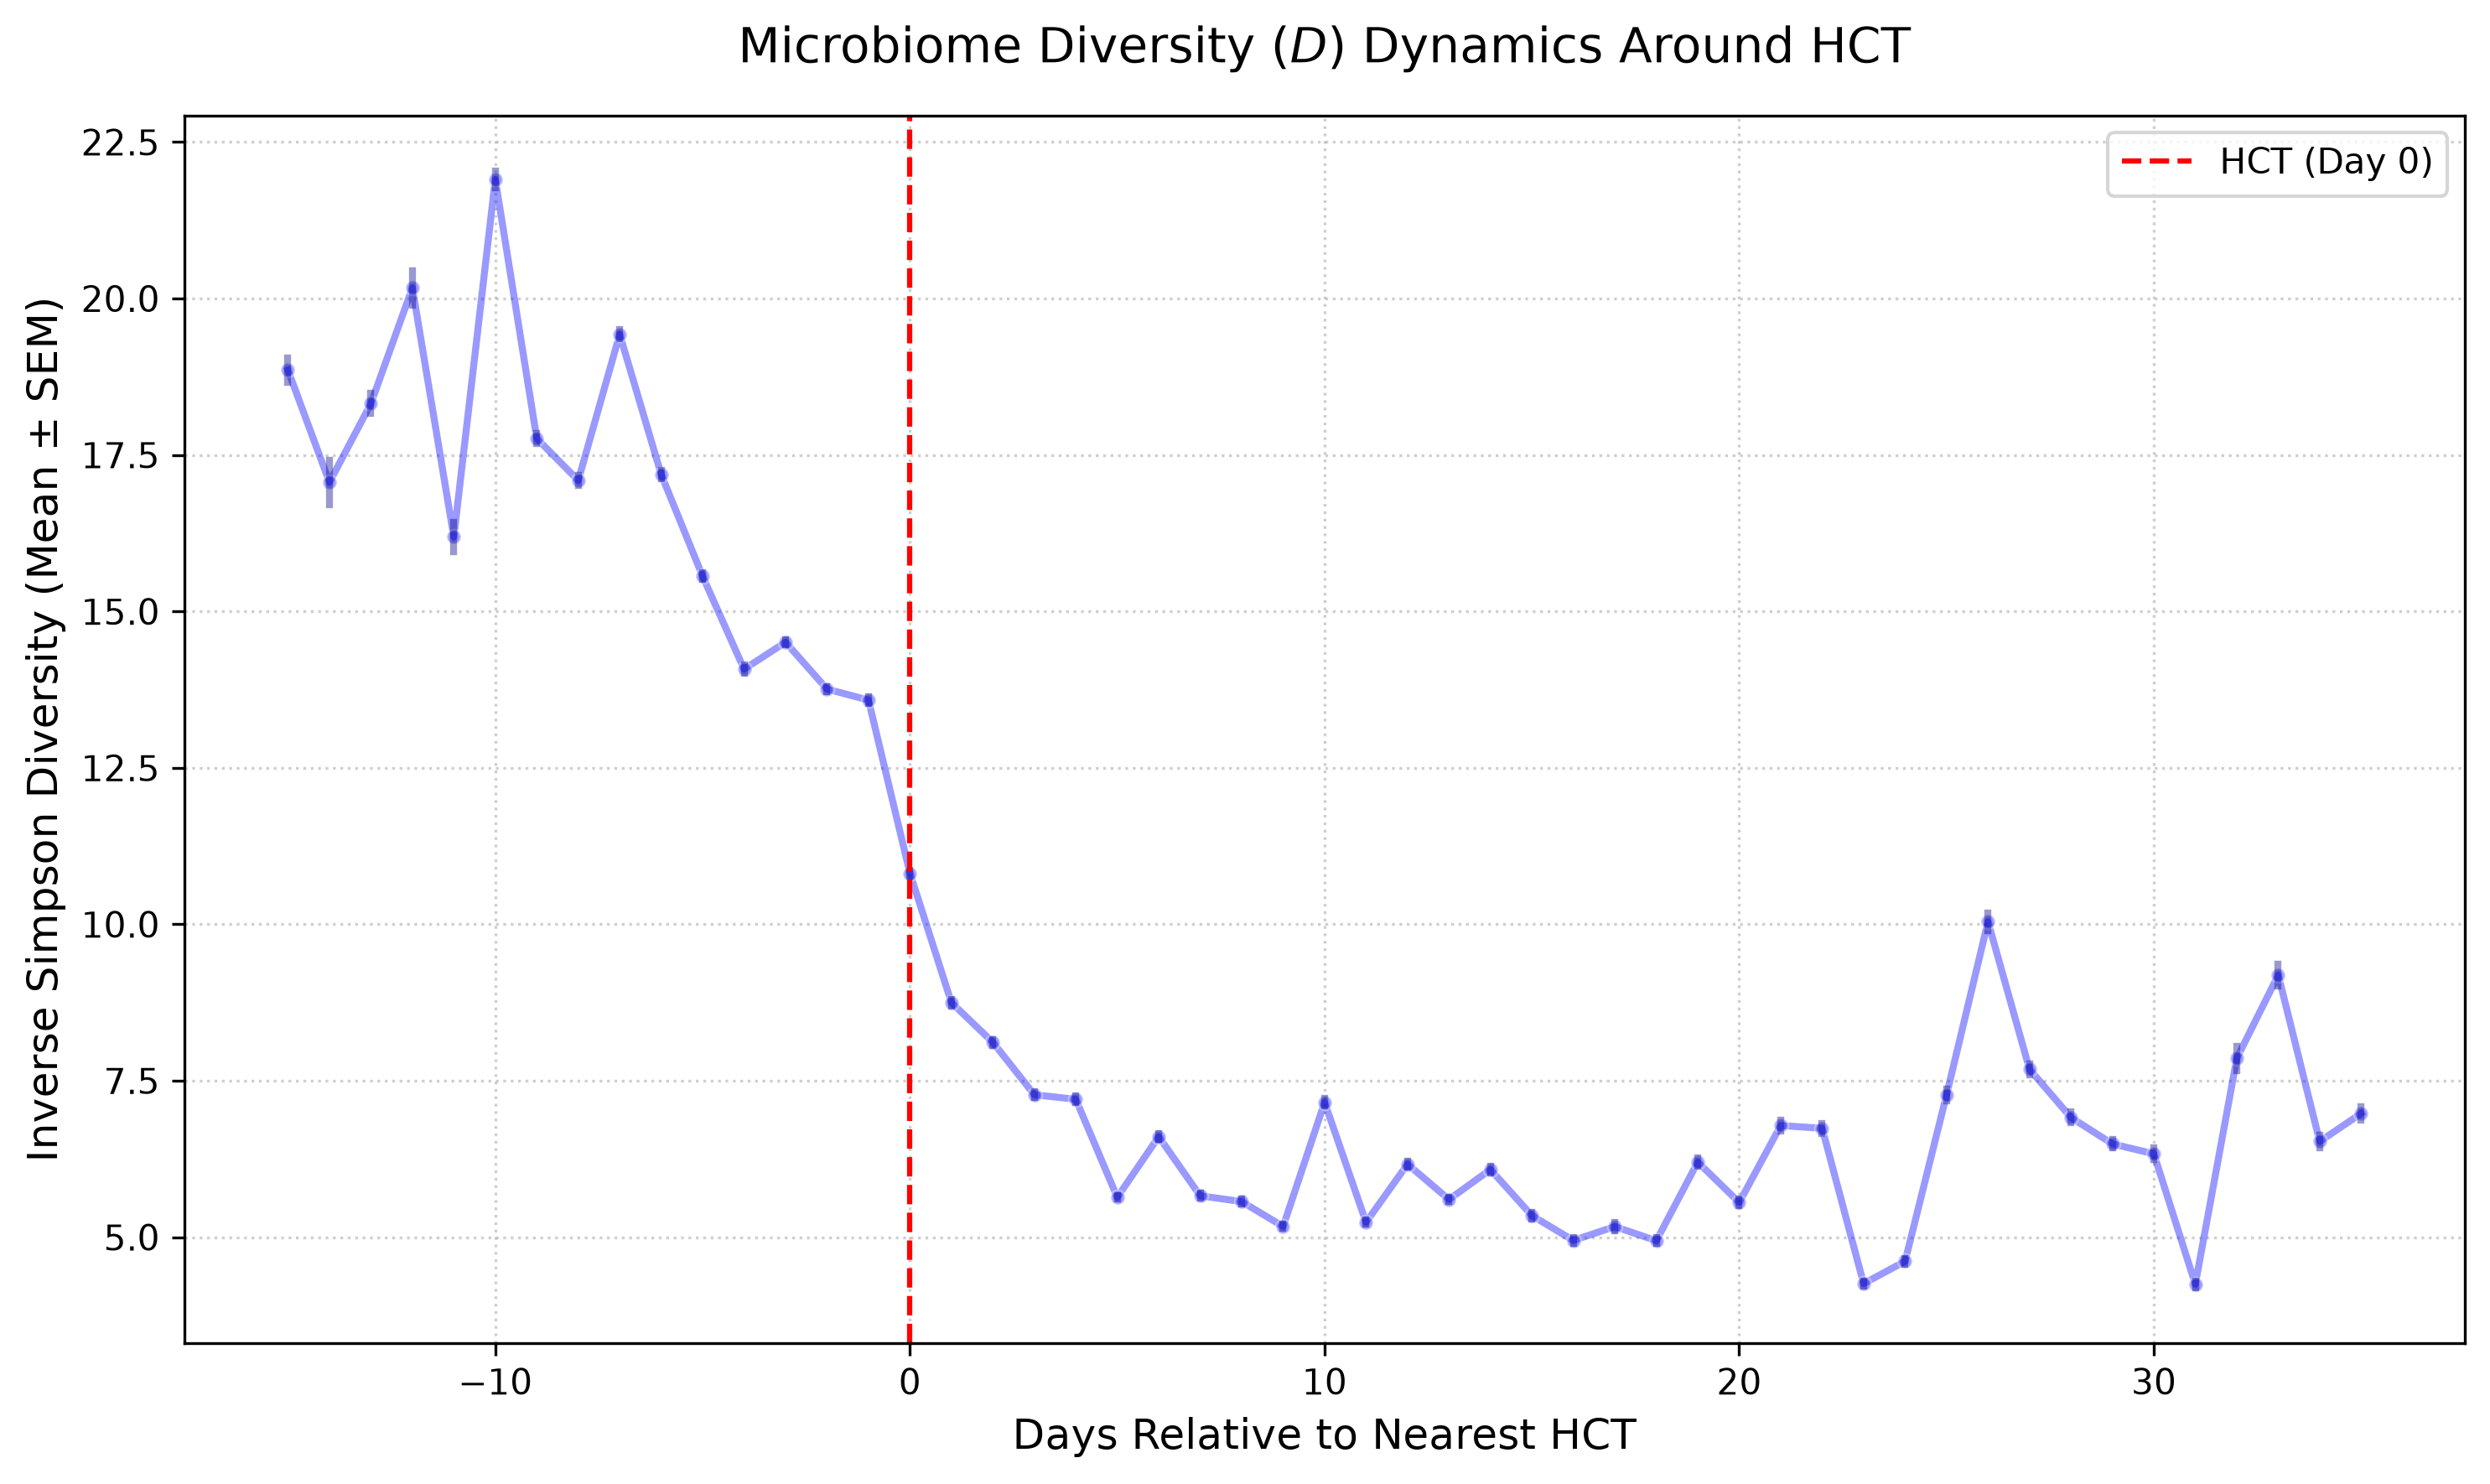

In [66]:
restricted_Dvals_merge_samples["BinDay"] = restricted_Dvals_merge_samples["DayRelativeToNearestHCT"].round().astype(int)
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=restricted_Dvals_merge_samples,
    x="BinDay",
    y="Dval",
    errorbar="se",  # Calculates ± SEM
    err_style="bars",  # Forces actual bars instead of a shaded band
    marker="o",
    markersize=4,
    linewidth=2,
    alpha=0.4,             # Makes the line/dots translucent (0 = invisible, 1 = solid)
    color="blue",      # Base color for line and dots
    
    # Style the error bars specifically
    err_kws={
        "ecolor": "darkblue",       # Make the SEM bars bright red (or "black", "darkorange", etc.)
        "elinewidth": 2,       # Make the error bar lines thicker
        "capthick": 2          # Make the horizontal caps thicker
    }
)

# Add vertical line at Day 0
plt.axvline(x=0, color="red", linestyle="--", label="HCT (Day 0)", linewidth=1.5)

# Labels and Styling
plt.title("Microbiome Diversity ($D$) Dynamics Around HCT", fontsize=14, pad=15)
plt.xlabel("Days Relative to Nearest HCT", fontsize=12)
plt.ylabel("Inverse Simpson Diversity (Mean ± SEM)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)  # Optional: adds a subtle grid for easier reading
plt.legend(frameon=True)

plt.tight_layout()  # Prevents labels from getting cut off at high resolution
plt.show()

In [59]:
# Calculate the exact Mean, Standard Deviation (s), Count (n), and SEM for each day
stats_check = restricted_Dvals_merge_samples.groupby("BinDay")["Dval"].agg(
    mean="mean",
    std="std",
    count="count"
)
stats_check["calculated_sem"] = stats_check["std"] / (stats_check["count"] ** 0.5)

print(stats_check.head(10))

             mean        std  count  calculated_sem
BinDay                                             
-15     18.855048   8.696014   1928        0.198046
-14     17.062729  10.812241    934        0.353787
-13     18.320047   9.918570   3806        0.160774
-12     20.170015  11.886731   1818        0.278782
-11     16.188330   8.151538   1225        0.232901
-10     21.904477  10.782483   6771        0.131037
-9      17.762844   8.967539  13982        0.075838
-8      17.091355   9.680819  13803        0.082400
-7      19.427343   9.645055  17242        0.073453
-6      17.189769   9.534940  22166        0.064043
